
# Figures

In [23]:
import json
import math
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.metrics import roc_curve, roc_auc_score

ROOT = Path.cwd().parent if Path.cwd().name == "figures" else Path.cwd()
sys.path.insert(0, str(ROOT))

from config import ALL_SIGNALS, PRIMARY_SIGNAL, RESULTS_DIR, FIGURES_DIR
from metrics.compute_metrics import load_scores

MICA_RESULTS_DIR = ROOT / "results_MiCA"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

METRICS_ALL_PATH   = RESULTS_DIR / "metrics_all.csv"
METRICS_1B_PATH    = RESULTS_DIR / "metrics_all_1B.csv"
METRICS_MICA_PATH  = MICA_RESULTS_DIR / "metrics_MiCA.csv"

AUROC_MISMATCH_TOL = 0.02

COLOR_FULL_FT = "#0072B2"   # blue
COLOR_LORA    = "#E69F00"   # orange
COLOR_MICA    = "#009E73"   # green
COLOR_DP      = "#D55E00"   # vermillion (red accent) -- base DP color, epsilon shades below
COLOR_BH      = "#CC79A7"   # reddish purple -- BH bound
COLOR_PINSKER = "#56B4E9"   # sky blue -- Pinsker bound
COLOR_ADV     = "#000000"   # black -- empirical advantage / TV

PALETTE_N_MEMBERS = {500: "#56B4E9", 2000: "#0072B2", 6000: "#D55E00"}
PALETTE_DP_EPS    = {1: "#F0E442", 4: "#E69F00", 8: "#D55E00"}  # light->dark = weak->strong privacy budget
SEED_MARKERS      = {0: "o", 1: "s", 2: "^"}

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "figure.dpi": 100,     
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

SAVE_DPI = 300


def save_fig(fig, name: str) -> tuple[Path, Path]:
    """Save fig as both vector PDF (for LaTeX) and 300dpi PNG (for quick preview)."""
    pdf_path = FIGURES_DIR / f"{name}.pdf"
    png_path = FIGURES_DIR / f"{name}.png"
    fig.savefig(pdf_path, dpi=SAVE_DPI)
    fig.savefig(png_path, dpi=SAVE_DPI)
    print(f"  saved -> {pdf_path.relative_to(ROOT)}")
    print(f"  saved -> {png_path.relative_to(ROOT)}")
    return pdf_path, png_path


print(f"ROOT             = {ROOT}")
print(f"RESULTS_DIR      = {RESULTS_DIR}")
print(f"MICA_RESULTS_DIR = {MICA_RESULTS_DIR}")
print(f"FIGURES_DIR      = {FIGURES_DIR}")


ROOT             = c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs
RESULTS_DIR      = C:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\results
MICA_RESULTS_DIR = c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\results_MiCA
FIGURES_DIR      = C:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\figures


In [24]:
dfs = {}
for name, path in [("metrics_all", METRICS_ALL_PATH),
                    ("metrics_all_1B", METRICS_1B_PATH),
                    ("metrics_MiCA", METRICS_MICA_PATH)]:
    print("=" * 78)
    print(f"{name}  <-  {path}")
    df = pd.read_csv(path)
    dfs[name] = df
    print(df.info())
    print(df.describe())
    for col in ["seed", "n_members", "epochs", "signal", "lora_rank", "dp_epsilon", "mica_rank"]:
        if col in df.columns:
            print(f"  unique {col}: {sorted(df[col].dropna().unique().tolist())}")
    if "perplexity" in df.columns:
        print(f"  perplexity all-NaN: {df['perplexity'].isna().all()}")
    print()

metrics_all  = dfs["metrics_all"]
metrics_1b   = dfs["metrics_all_1B"]
metrics_mica = dfs["metrics_MiCA"]


metrics_all  <-  C:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\results\metrics_all.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   seed                552 non-null    int64  
 1   n_members           552 non-null    int64  
 2   epochs              552 non-null    int64  
 3   signal              552 non-null    object 
 4   auroc               552 non-null    float64
 5   tpr_at_fpr_1pct     552 non-null    float64
 6   tpr_at_fpr_01pct    552 non-null    float64
 7   adv                 552 non-null    float64
 8   tv_empirical        552 non-null    float64
 9   kl_seq              552 non-null    float64
 10  pinsker_seq         552 non-null    float64
 11  bh_seq              552 non-null    float64
 12  dp_epsilon          72 non-null     float64
 13  perplexity          0 non-null      float64
 14  lora_rank   

In [29]:
for label, sample_path in [
    ("full FT",  RESULTS_DIR / "signals_N2000_seed0_epoch5.jsonl"),
    ("LoRA r16", RESULTS_DIR / "signals_lora_r16_N2000_seed0_epoch5.jsonl"),
    ("MiCA r16", MICA_RESULTS_DIR / "signals_mica_r16_N2000_seed0_epoch5.jsonl"),
]:
    print(f"--- {label}: {sample_path.name} ---")
    with sample_path.open(encoding="utf-8") as fh:
        splits = set()
        for i, line in enumerate(fh):
            rec = json.loads(line)
            if i < 2:
                print(" ", rec)
            splits.add(rec["split"])
    print(f"  unique split values: {splits}")
    print()


--- full FT: signals_N2000_seed0_epoch5.jsonl ---
  {'id': 1245, 'split': 'member', 's_loss': -1.8654754161834717, 's_ref': 2.1580965518951416, 's_zlib': -0.004734709178130639, 's_mink': -5.843130111694336}
  {'id': 7057, 'split': 'member', 's_loss': -1.4566806554794312, 's_ref': 2.694873809814453, 's_zlib': -0.0025028877241914625, 's_mink': -4.7943034172058105}
  unique split values: {'member', 'nonmember'}

--- LoRA r16: signals_lora_r16_N2000_seed0_epoch5.jsonl ---
  {'id': 1245, 'split': 'member', 's_loss': -3.4289729595184326, 's_ref': 0.5945990085601807, 's_zlib': -0.008702977054615311, 's_mink': -8.04088306427002}
  {'id': 7057, 'split': 'member', 's_loss': -3.5124831199645996, 's_ref': 0.6390714645385742, 's_zlib': -0.006035194364200343, 's_mink': -7.9155659675598145}
  unique split values: {'member', 'nonmember'}

--- MiCA r16: signals_mica_r16_N2000_seed0_epoch5.jsonl ---
  {'id': 1245, 'split': 'member', 's_loss': -3.501249074935913, 's_ref': 0.522322416305542, 's_zlib': -0.

In [30]:
lora_rows = metrics_all[metrics_all["lora_rank"].notna()]
lora_seeds = sorted(lora_rows["seed"].unique().tolist())
print(f"LoRA seeds actually present in metrics_all.csv: {lora_seeds}")


LoRA seeds actually present in metrics_all.csv: [0]


In [32]:
def sklearn_auroc(signals_path: Path, signal: str) -> tuple[float, np.ndarray, np.ndarray]:
    """Compute (auroc, fpr, tpr) for one signal from a raw signals_*.jsonl file via sklearn."""
    scores = load_scores(signals_path)
    sc_m, sc_nm = scores[signal]
    y_true  = [1] * len(sc_m) + [0] * len(sc_nm)
    y_score = list(sc_m) + list(sc_nm)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auroc = float(roc_auc_score(y_true, y_score))
    return auroc, fpr, tpr


def cross_check_auroc(sklearn_val: float, csv_val: float, context: str) -> None:
    if csv_val is None or (isinstance(csv_val, float) and math.isnan(csv_val)):
        return
    diff = abs(sklearn_val - csv_val)
    if diff > AUROC_MISMATCH_TOL:
        warnings.warn(
            f"[AUROC MISMATCH] {context}: sklearn={sklearn_val:.4f} vs csv={csv_val:.4f} "
            f"(diff={diff:.4f} > tol={AUROC_MISMATCH_TOL}) -- check y_true/y_score construction."
        )


def csv_auroc_lookup(df: pd.DataFrame, **filters) -> float | None:
    sub = df.copy()
    for k, v in filters.items():
        sub = sub[sub[k] == v]
    if sub.empty:
        return None
    return float(sub["auroc"].iloc[0])

print("Helpers defined: sklearn_auroc(), cross_check_auroc(), csv_auroc_lookup().")


Helpers defined: sklearn_auroc(), cross_check_auroc(), csv_auroc_lookup().


## Figure 1 — Phase transition / bound tightness (headline figure)


  saved -> figures\fig1_phase_transition.pdf
  saved -> figures\fig1_phase_transition.png


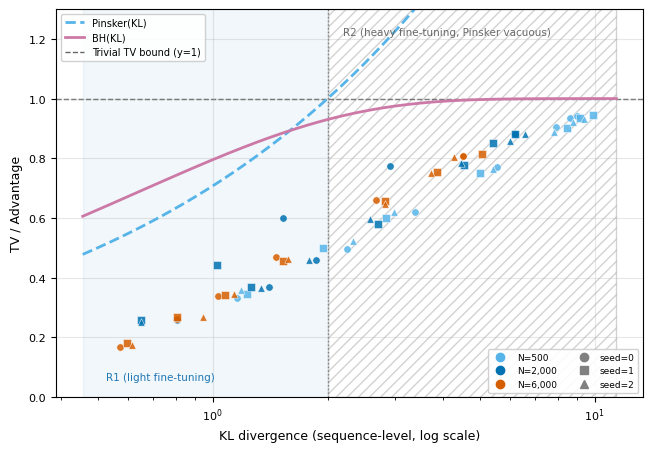

Figure 1: 63 points, KL in [0.571, 9.912]


In [43]:
def fig1_phase_transition(df: pd.DataFrame):
    sub = df[
        (df["signal"] == "ref")
        & df["lora_rank"].isna()
        & df["mica_rank"].isna()
        & df["dp_epsilon"].isna()
    ].copy()
    assert not sub.empty, "Figure 1: no full-FT signal=ref rows found"
    assert (sub["kl_seq"] > 0).all(), "Figure 1: kl_seq must be > 0 for a log-scale x-axis"

    kl_min, kl_max = sub["kl_seq"].min(), sub["kl_seq"].max()
    kl_grid = np.logspace(np.log10(kl_min * 0.8), np.log10(kl_max * 1.15), 400)
    pinsker_curve = np.sqrt(kl_grid / 2.0)
    bh_curve      = np.sqrt(1.0 - np.exp(-kl_grid))

    fig, ax = plt.subplots(figsize=(6.6, 4.6))

    # R1 / R2 regime shading (KL <= 2 vs KL > 2)
    ax.axvspan(kl_grid[0], 2.0, color="tab:blue", alpha=0.06, zorder=0)
    ax.axvspan(2.0, kl_grid[-1], facecolor="none", edgecolor="gray",
               hatch="///", alpha=0.35, zorder=0)
    ax.text(kl_grid[0] * 1.15, 0.05, "R1 (light fine-tuning)",
            fontsize=7.5, color="tab:blue", va="bottom")
    ax.text(2.2, 1.24, "R2 (heavy fine-tuning, Pinsker vacuous)",
            fontsize=7.5, color="dimgray", va="top")
    ax.axvline(2.0, color="gray", ls=":", lw=1, zorder=1)

    ax.plot(kl_grid, pinsker_curve, color=COLOR_PINSKER, ls="--", lw=2,
            label="Pinsker(KL)", zorder=2)
    ax.plot(kl_grid, bh_curve, color=COLOR_BH, ls="-", lw=2,
            label="BH(KL)", zorder=2)
    ax.axhline(1.0, color="black", ls="--", lw=1, alpha=0.6,
               label="Trivial TV bound (y=1)", zorder=1)

    for n_members, grp in sub.groupby("n_members"):
        color = PALETTE_N_MEMBERS.get(n_members, "gray")
        for seed, sgrp in grp.groupby("seed"):
            marker = SEED_MARKERS.get(seed, "o")
            ax.scatter(sgrp["kl_seq"], sgrp["adv"], color=color, marker=marker,
                       s=28, alpha=0.85, edgecolor="white", linewidth=0.4, zorder=3,
                       label=f"N={n_members:,}, seed={seed}")

    ax.set_xscale("log")
    ax.set_xlabel("KL divergence (sequence-level, log scale)")
    ax.set_ylabel("TV / Advantage")
    ax.set_ylim(0, 1.3)
    #ax.set_title("Bound Tightness: Empirical Advantage vs KL Divergence")

    # Two-part legend: bound/reference lines, then a compact N-members color key
    bound_handles, bound_labels = ax.get_legend_handles_labels()
    bound_handles = bound_handles[:3]
    bound_labels  = bound_labels[:3]
    n_handles = [Line2D([0], [0], marker="o", color=c, lw=0, markersize=6,
                         label=f"N={n:,}") for n, c in PALETTE_N_MEMBERS.items()]
    seed_handles = [Line2D([0], [0], marker=m, color="gray", lw=0, markersize=6,
                            label=f"seed={s}") for s, m in SEED_MARKERS.items()]
    leg1 = ax.legend(bound_handles, bound_labels, loc="upper left", framealpha=0.9)
    ax.add_artist(leg1)
    ax.legend(n_handles + seed_handles, [h.get_label() for h in n_handles + seed_handles],
              loc="lower right", ncol=2, framealpha=0.9, fontsize=6.5)

    fig.tight_layout()
    save_fig(fig, "fig1_phase_transition")
    plt.show()
    return sub


fig1_sub = fig1_phase_transition(metrics_all)
print(f"Figure 1: {len(fig1_sub)} points, KL in [{fig1_sub['kl_seq'].min():.3f}, {fig1_sub['kl_seq'].max():.3f}]")


## Figure 2 — Bounds per epoch, full fine-tuning

  saved -> figures\fig2_bounds_per_epoch.pdf
  saved -> figures\fig2_bounds_per_epoch.png


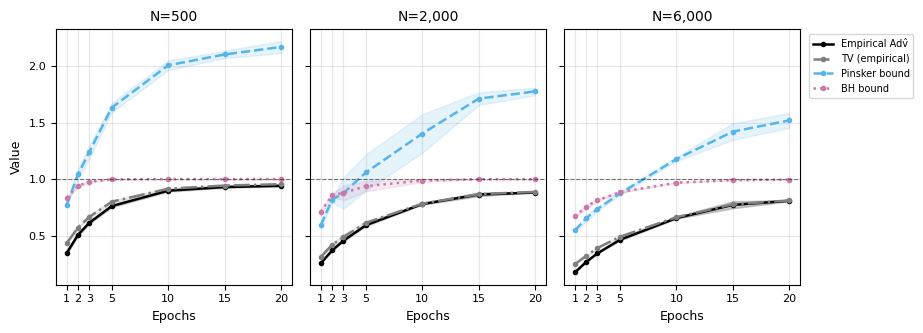

In [41]:
def fig2_bounds_per_epoch(df: pd.DataFrame):
    sub = df[
        (df["signal"] == "ref")
        & df["lora_rank"].isna()
        & df["mica_rank"].isna()
        & df["dp_epsilon"].isna()
    ].copy()
    assert not sub.empty, "Figure 2: no full-FT signal=ref rows found"

    ns = sorted(sub["n_members"].unique())
    line_specs = [
        ("adv",         COLOR_ADV,     "-",  "Empirical Adv̂"),
        ("tv_empirical", "tab:gray",   "-.", "TV (empirical)"),
        ("pinsker_seq",  COLOR_PINSKER, "--", "Pinsker bound"),
        ("bh_seq",       COLOR_BH,      ":",  "BH bound"),
    ]

    fig, axes = plt.subplots(1, len(ns), figsize=(3.1 * len(ns), 3.4), sharex="col", sharey=True)
    if len(ns) == 1:
        axes = [axes]

    for col_idx, n_members in enumerate(ns):
        grp = sub[sub["n_members"] == n_members].sort_values("epochs")
        epochs = sorted(grp["epochs"].unique())

        ax = axes[col_idx]
        agg = grp.groupby("epochs")[["adv", "tv_empirical", "pinsker_seq", "bh_seq"]].agg(["mean", "std"])
        for col, color, ls, label in line_specs:
            mean = agg[(col, "mean")].reindex(epochs).values
            std  = np.nan_to_num(agg[(col, "std")].reindex(epochs).values, nan=0.0)
            ax.plot(epochs, mean, color=color, ls=ls, lw=1.8, marker="o", ms=3, label=label)
            if np.any(std > 0):
                ax.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.15)
        ax.axhline(1.0, color="black", ls="--", lw=0.8, alpha=0.5)
        ax.set_title(f"N={n_members:,}")
        ax.set_xlabel("Epochs")
        ax.set_xticks(epochs)
        if col_idx == 0:
            ax.set_ylabel("Value")

    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=7)
    fig.tight_layout()
    save_fig(fig, "fig2_bounds_per_epoch")
    plt.show()
    return sub


fig2_sub = fig2_bounds_per_epoch(metrics_all)

## Figure 3 — Full FT vs LoRA vs MiCA

  saved -> figures\fig3_method_comparison.pdf
  saved -> figures\fig3_method_comparison.png


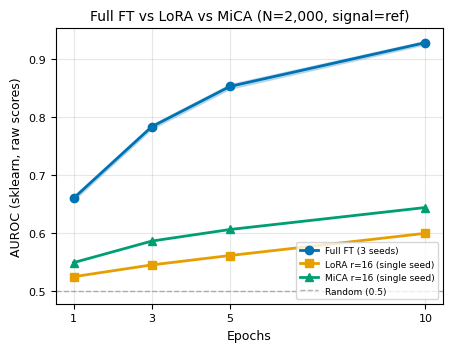

In [44]:
COMMON_EPOCHS = [1, 3, 5, 10]
N_FIG3 = 2000
SIG_FIG3 = "ref"

def _full_ft_auroc_by_epoch(epochs, n_members, metrics_df):
    """Per-seed sklearn AUROC for full FT, cross-checked against the CSV."""
    full_ft = metrics_df[metrics_df["lora_rank"].isna() & metrics_df["mica_rank"].isna()
                          & metrics_df["dp_epsilon"].isna()]
    rows = []
    for seed in [0, 1, 2]:
        for ep in epochs:
            path = RESULTS_DIR / f"signals_N{n_members}_seed{seed}_epoch{ep}.jsonl"
            if not path.exists():
                print(f"  [warn] missing {path.name}")
                continue
            auroc, _, _ = sklearn_auroc(path, SIG_FIG3)
            csv_sub = full_ft[(full_ft["seed"] == seed) & (full_ft["n_members"] == n_members)
                               & (full_ft["epochs"] == ep) & (full_ft["signal"] == SIG_FIG3)]
            csv_val = float(csv_sub["auroc"].iloc[0]) if not csv_sub.empty else None
            cross_check_auroc(auroc, csv_val, f"Full FT N={n_members} seed={seed} epoch={ep}")
            rows.append({"epochs": ep, "seed": seed, "auroc": auroc})
    return pd.DataFrame(rows)


def _rank_variant_auroc_by_epoch(epochs, n_members, prefix, rank, mica_flag, metrics_df):
    rows = []
    for ep in epochs:
        if mica_flag:
            path = MICA_RESULTS_DIR / f"signals_mica_r{rank}_N{n_members}_seed0_epoch{ep}.jsonl"
        else:
            path = RESULTS_DIR / f"signals_lora_r{rank}_N{n_members}_seed0_epoch{ep}.jsonl"
        if not path.exists():
            print(f"  [warn] missing {path.name}")
            continue
        auroc, _, _ = sklearn_auroc(path, SIG_FIG3)
        rank_col = "mica_rank" if mica_flag else "lora_rank"
        csv_sub = metrics_df[(metrics_df[rank_col] == rank) & (metrics_df["seed"] == 0)
                              & (metrics_df["n_members"] == n_members) & (metrics_df["epochs"] == ep)
                              & (metrics_df["signal"] == SIG_FIG3)]
        csv_val = float(csv_sub["auroc"].iloc[0]) if not csv_sub.empty else None
        cross_check_auroc(auroc, csv_val, f"{prefix} r={rank} N={n_members} epoch={ep}")
        rows.append({"epochs": ep, "auroc": auroc})
    return pd.DataFrame(rows)


def fig3_method_comparison(metrics_all_df, metrics_mica_df):
    full_df  = _full_ft_auroc_by_epoch(COMMON_EPOCHS, N_FIG3, metrics_all_df)
    lora_df  = _rank_variant_auroc_by_epoch(COMMON_EPOCHS, N_FIG3, "LoRA", 16, False, metrics_all_df)
    mica_df  = _rank_variant_auroc_by_epoch(COMMON_EPOCHS, N_FIG3, "MiCA", 16, True, metrics_mica_df)

    assert not full_df.empty and not lora_df.empty and not mica_df.empty, \
        "Figure 3: one of Full FT / LoRA(r16) / MiCA(r16) has no raw-file AUROC data"

    fig, ax = plt.subplots(figsize=(4.6, 3.6))

    full_agg = full_df.groupby("epochs")["auroc"].agg(["mean", "std"]).reindex(COMMON_EPOCHS)
    mean = full_agg["mean"].values
    std  = np.nan_to_num(full_agg["std"].values, nan=0.0)
    ax.plot(COMMON_EPOCHS, mean, color=COLOR_FULL_FT, lw=2, marker="o", label="Full FT (3 seeds)")
    if np.any(std > 0):
        ax.fill_between(COMMON_EPOCHS, mean - std, mean + std, color=COLOR_FULL_FT, alpha=0.2)

    lora_sorted = lora_df.sort_values("epochs")
    ax.plot(lora_sorted["epochs"], lora_sorted["auroc"], color=COLOR_LORA, lw=2, marker="s",
            label="LoRA r=16 (single seed)")

    mica_sorted = mica_df.sort_values("epochs")
    ax.plot(mica_sorted["epochs"], mica_sorted["auroc"], color=COLOR_MICA, lw=2, marker="^",
            label="MiCA r=16 (single seed)")

    ax.axhline(0.5, color="gray", ls="--", lw=1, alpha=0.6, label="Random (0.5)")
    ax.set_xticks(COMMON_EPOCHS)
    ax.set_xlabel("Epochs")
    ax.set_ylabel("AUROC (sklearn, raw scores)")
    ax.set_title(f"Full FT vs LoRA vs MiCA (N={N_FIG3:,}, signal={SIG_FIG3})")
    ax.legend(fontsize=6.5, loc="lower right")
    fig.tight_layout()
    save_fig(fig, "fig3_method_comparison")
    plt.show()
    return full_df, lora_df, mica_df


fig3_full, fig3_lora, fig3_mica = fig3_method_comparison(metrics_all, metrics_mica)


  saved -> figures\fig3b_roc_curves_full_vs_lora_vs_mica.pdf
  saved -> figures\fig3b_roc_curves_full_vs_lora_vs_mica.png


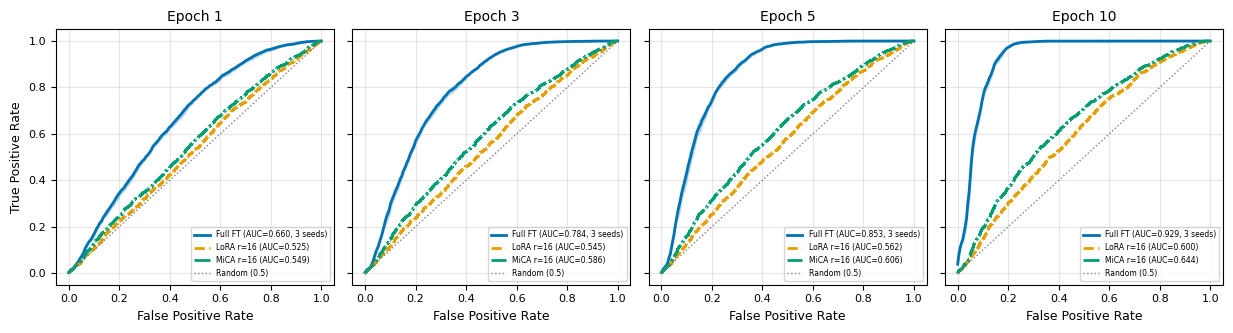

In [45]:
def _mean_roc(paths, signal, n_grid=200):
    """Vertically-averaged ROC curve (mean +/- std TPR) across multiple signal files,
    interpolated onto a common FPR grid -- standard approach for averaging ROC curves
    across seeds/folds."""
    fpr_grid = np.linspace(0, 1, n_grid)
    tprs, aurocs = [], []
    for path in paths:
        if not path.exists():
            print(f"  [warn] missing {path.name}")
            continue
        auroc, fpr, tpr = sklearn_auroc(path, signal)
        tprs.append(np.interp(fpr_grid, fpr, tpr))
        aurocs.append(auroc)
    if not tprs:
        return None
    tprs = np.vstack(tprs)
    return {
        "fpr": fpr_grid,
        "tpr_mean": tprs.mean(axis=0),
        "tpr_std": tprs.std(axis=0),
        "auroc_mean": float(np.mean(aurocs)),
        "auroc_std": float(np.std(aurocs)),
        "n": len(tprs),
    }


def fig3b_roc_curves_by_epoch(epochs=COMMON_EPOCHS, n_members=N_FIG3, signal=SIG_FIG3):
    ncols = len(epochs)
    fig, axes = plt.subplots(1, ncols, figsize=(3.1 * ncols, 3.4), sharey=True)
    if ncols == 1:
        axes = [axes]

    for ax, ep in zip(axes, epochs):
        # Full FT: mean ROC + std band across the 3 seeds
        full_paths = [RESULTS_DIR / f"signals_N{n_members}_seed{s}_epoch{ep}.jsonl" for s in [0, 1, 2]]
        full = _mean_roc(full_paths, signal)
        if full is not None:
            ax.plot(full["fpr"], full["tpr_mean"], color=COLOR_FULL_FT, lw=2,
                     label=f"Full FT (AUC={full['auroc_mean']:.3f}, {full['n']} seeds)")
            ax.fill_between(full["fpr"], full["tpr_mean"] - full["tpr_std"],
                             full["tpr_mean"] + full["tpr_std"], color=COLOR_FULL_FT, alpha=0.2)

        # LoRA r=16, single seed
        lora_path = RESULTS_DIR / f"signals_lora_r16_N{n_members}_seed0_epoch{ep}.jsonl"
        if lora_path.exists():
            auroc, fpr, tpr = sklearn_auroc(lora_path, signal)
            ax.plot(fpr, tpr, color=COLOR_LORA, lw=2, ls="--", label=f"LoRA r=16 (AUC={auroc:.3f})")
        else:
            print(f"  [warn] missing {lora_path.name}")

        # MiCA r=16, single seed
        mica_path = MICA_RESULTS_DIR / f"signals_mica_r16_N{n_members}_seed0_epoch{ep}.jsonl"
        if mica_path.exists():
            auroc, fpr, tpr = sklearn_auroc(mica_path, signal)
            ax.plot(fpr, tpr, color=COLOR_MICA, lw=2, ls="-.", label=f"MiCA r=16 (AUC={auroc:.3f})")
        else:
            print(f"  [warn] missing {mica_path.name}")

        ax.plot([0, 1], [0, 1], color="gray", ls=":", lw=1, label="Random (0.5)")
        ax.set_xlabel("False Positive Rate")
        if ax is axes[0]:
            ax.set_ylabel("True Positive Rate")
        ax.set_title(f"Epoch {ep}")
        ax.legend(fontsize=5.5, loc="lower right")

    #fig.suptitle(f"ROC Curves: Full FT vs LoRA vs MiCA (N={n_members:,}, signal={signal})",
    #             fontsize=10, y=1.03)
    fig.tight_layout()
    save_fig(fig, "fig3b_roc_curves_full_vs_lora_vs_mica")
    plt.show()


fig3b_roc_curves_by_epoch()

### Appendix table — rank sensitivity (epoch=10, N=2000)

AUROC (sklearn, raw scores) for LoRA and MiCA at rank in {4, 16, 64}, epoch=10, N=2000 — the
rank-sensitivity check kept out of the main figure to avoid clutter.


In [10]:
def rank_sensitivity_table(metrics_all_df, metrics_mica_df, epoch=10, n_members=2000):
    rows = []
    for rank in [4, 16, 64]:
        lora_path = RESULTS_DIR / f"signals_lora_r{rank}_N{n_members}_seed0_epoch{epoch}.jsonl"
        if lora_path.exists():
            auroc, _, _ = sklearn_auroc(lora_path, SIG_FIG3)
            csv_sub = metrics_all_df[(metrics_all_df["lora_rank"] == rank) & (metrics_all_df["seed"] == 0)
                                      & (metrics_all_df["n_members"] == n_members)
                                      & (metrics_all_df["epochs"] == epoch) & (metrics_all_df["signal"] == SIG_FIG3)]
            csv_val = float(csv_sub["auroc"].iloc[0]) if not csv_sub.empty else None
            cross_check_auroc(auroc, csv_val, f"LoRA r={rank} N={n_members} epoch={epoch}")
            rows.append({"method": "LoRA", "rank": rank, "auroc": auroc})

        mica_path = MICA_RESULTS_DIR / f"signals_mica_r{rank}_N{n_members}_seed0_epoch{epoch}.jsonl"
        if mica_path.exists():
            auroc, _, _ = sklearn_auroc(mica_path, SIG_FIG3)
            csv_sub = metrics_mica_df[(metrics_mica_df["mica_rank"] == rank) & (metrics_mica_df["seed"] == 0)
                                       & (metrics_mica_df["n_members"] == n_members)
                                       & (metrics_mica_df["epochs"] == epoch) & (metrics_mica_df["signal"] == SIG_FIG3)]
            csv_val = float(csv_sub["auroc"].iloc[0]) if not csv_sub.empty else None
            cross_check_auroc(auroc, csv_val, f"MiCA r={rank} N={n_members} epoch={epoch}")
            rows.append({"method": "MiCA", "rank": rank, "auroc": auroc})

    table = pd.DataFrame(rows).pivot(index="rank", columns="method", values="auroc")
    out_path = FIGURES_DIR / "table_rank_sensitivity_epoch10_N2000.csv"
    table.to_csv(out_path)
    print(f"  saved -> {out_path.relative_to(ROOT)}")
    return table


rank_table = rank_sensitivity_table(metrics_all, metrics_mica)
rank_table


  saved -> figures\table_rank_sensitivity_epoch10_N2000.csv


method,LoRA,MiCA
rank,,
4,0.587116,0.624727
16,0.599855,0.644358
64,0.602792,0.654946


## Figure 4 — DP-SGD vs AUROC, full fine-tuning


DP configs found: [(500, 5), (2000, 5), (6000, 1), (6000, 2), (6000, 3), (6000, 5)]
  saved -> figures\fig4_dp_vs_auroc.pdf
  saved -> figures\fig4_dp_vs_auroc.png


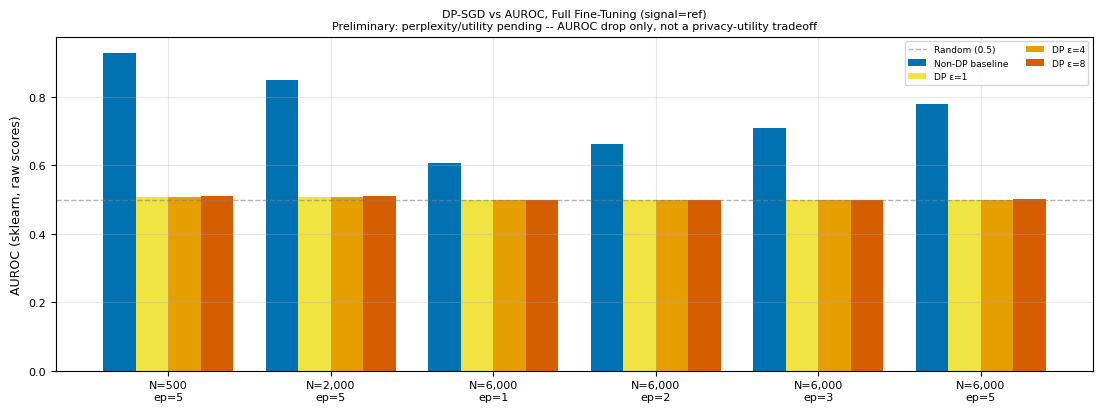

In [46]:
def fig4_dp_vs_auroc(df: pd.DataFrame):
    dp_sub = df[(df["signal"] == "ref") & df["dp_epsilon"].notna()].copy()
    assert not dp_sub.empty, "Figure 4: no DP rows found for signal=ref"

    configs = sorted(set(zip(dp_sub["n_members"], dp_sub["epochs"])))
    print(f"DP configs found: {configs}")
    eps_values = sorted(dp_sub["dp_epsilon"].unique())

    bar_data = {}  # config -> {"nondp": auroc, eps: auroc}
    for n_members, epoch in configs:
        nondp_path = RESULTS_DIR / f"signals_N{n_members}_seed0_epoch{epoch}.jsonl"
        entry = {}
        if nondp_path.exists():
            auroc, _, _ = sklearn_auroc(nondp_path, "ref")
            csv_sub = df[(df["lora_rank"].isna()) & (df["mica_rank"].isna()) & (df["dp_epsilon"].isna())
                         & (df["seed"] == 0) & (df["n_members"] == n_members) & (df["epochs"] == epoch)
                         & (df["signal"] == "ref")]
            csv_val = float(csv_sub["auroc"].iloc[0]) if not csv_sub.empty else None
            cross_check_auroc(auroc, csv_val, f"non-DP baseline N={n_members} epoch={epoch}")
            entry["nondp"] = auroc
        else:
            print(f"  [warn] missing non-DP baseline {nondp_path.name}")
            entry["nondp"] = np.nan

        for eps in eps_values:
            eps_str = f"{eps:g}"
            dp_path = RESULTS_DIR / f"signals_dp_eps{eps_str}_N{n_members}_seed0_epoch{epoch}.jsonl"
            if dp_path.exists():
                auroc, _, _ = sklearn_auroc(dp_path, "ref")
                csv_sub = df[(df["dp_epsilon"] == eps) & (df["seed"] == 0) & (df["n_members"] == n_members)
                             & (df["epochs"] == epoch) & (df["signal"] == "ref")]
                csv_val = float(csv_sub["auroc"].iloc[0]) if not csv_sub.empty else None
                cross_check_auroc(auroc, csv_val, f"DP eps={eps} N={n_members} epoch={epoch}")
                entry[eps] = auroc
            else:
                entry[eps] = np.nan
        bar_data[(n_members, epoch)] = entry

    group_labels = [f"N={n:,}\nep={e}" for n, e in configs]
    n_groups = len(configs)
    n_bars_per_group = 1 + len(eps_values)
    bar_width = 0.8 / n_bars_per_group
    x = np.arange(n_groups)

    fig, ax = plt.subplots(figsize=(1.6 * n_groups + 1.5, 4.2))

    offset0 = -0.4 + bar_width / 2
    nondp_vals = [bar_data[cfg]["nondp"] for cfg in configs]
    ax.bar(x + offset0, nondp_vals, width=bar_width, color=COLOR_FULL_FT,
           label="Non-DP baseline")

    for i, eps in enumerate(eps_values, start=1):
        vals = [bar_data[cfg][eps] for cfg in configs]
        color = PALETTE_DP_EPS.get(int(eps), COLOR_DP)
        ax.bar(x + offset0 + i * bar_width, vals, width=bar_width, color=color,
               label=f"DP \u03b5={eps:g}")

    ax.axhline(0.5, color="gray", ls="--", lw=1, alpha=0.6, label="Random (0.5)")
    ax.set_xticks(x)
    ax.set_xticklabels(group_labels)
    ax.set_ylabel("AUROC (sklearn, raw scores)")
    ax.set_title("DP-SGD vs AUROC, Full Fine-Tuning (signal=ref)\n"
                  "Preliminary: perplexity/utility pending -- AUROC drop only, not a privacy-utility tradeoff",
                  fontsize=8)
    ax.legend(fontsize=6.5, ncol=2)
    fig.tight_layout()
    save_fig(fig, "fig4_dp_vs_auroc")
    plt.show()
    return bar_data


fig4_data = fig4_dp_vs_auroc(metrics_all)


DP configs found: [(500, 5), (2000, 5), (6000, 1), (6000, 2), (6000, 3), (6000, 5)]
  saved -> figures\fig4b_dp_roc_curves.pdf
  saved -> figures\fig4b_dp_roc_curves.png


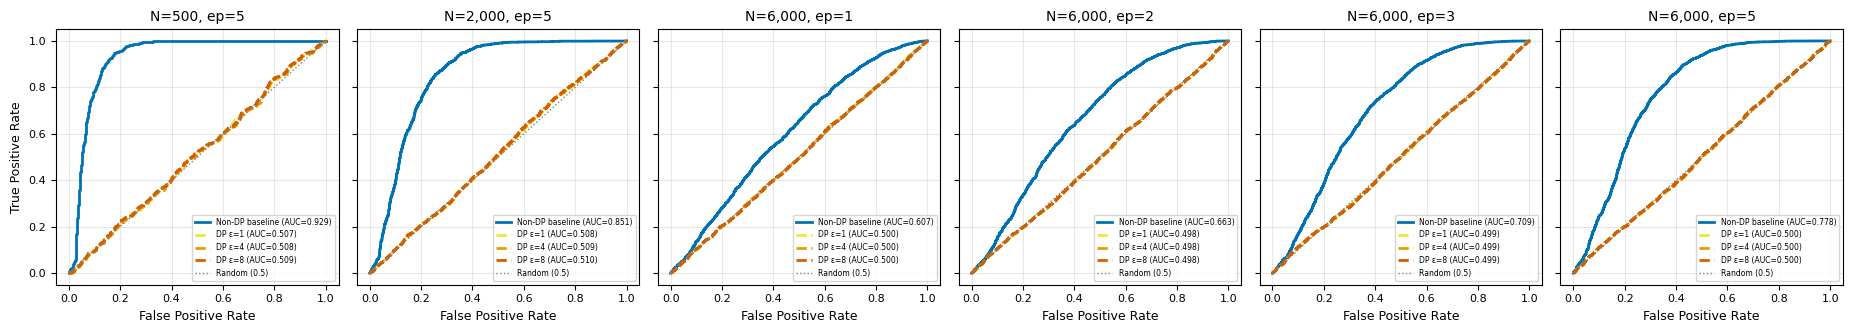

In [48]:
def fig4b_dp_roc_curves(df: pd.DataFrame):
    dp_sub = df[(df["signal"] == "ref") & df["dp_epsilon"].notna()].copy()
    assert not dp_sub.empty, "Figure 4b: no DP rows found for signal=ref"

    configs = sorted(set(zip(dp_sub["n_members"], dp_sub["epochs"])))
    print(f"DP configs found: {configs}")
    eps_values = sorted(dp_sub["dp_epsilon"].unique())

    ncols = len(configs)
    fig, axes = plt.subplots(1, ncols, figsize=(3.1 * ncols, 3.4), sharey=True)
    if ncols == 1:
        axes = [axes]

    for ax, (n_members, epoch) in zip(axes, configs):
        nondp_path = RESULTS_DIR / f"signals_N{n_members}_seed0_epoch{epoch}.jsonl"
        if nondp_path.exists():
            auroc, fpr, tpr = sklearn_auroc(nondp_path, "ref")
            csv_sub = df[(df["lora_rank"].isna()) & (df["mica_rank"].isna()) & (df["dp_epsilon"].isna())
                         & (df["seed"] == 0) & (df["n_members"] == n_members) & (df["epochs"] == epoch)
                         & (df["signal"] == "ref")]
            csv_val = float(csv_sub["auroc"].iloc[0]) if not csv_sub.empty else None
            cross_check_auroc(auroc, csv_val, f"non-DP baseline N={n_members} epoch={epoch}")
            ax.plot(fpr, tpr, color=COLOR_FULL_FT, lw=2, label=f"Non-DP baseline (AUC={auroc:.3f})")
        else:
            print(f"  [warn] missing non-DP baseline {nondp_path.name}")

        for eps in eps_values:
            eps_str = f"{eps:g}"
            dp_path = RESULTS_DIR / f"signals_dp_eps{eps_str}_N{n_members}_seed0_epoch{epoch}.jsonl"
            color = PALETTE_DP_EPS.get(int(eps), COLOR_DP)
            if dp_path.exists():
                auroc, fpr, tpr = sklearn_auroc(dp_path, "ref")
                csv_sub = df[(df["dp_epsilon"] == eps) & (df["seed"] == 0) & (df["n_members"] == n_members)
                             & (df["epochs"] == epoch) & (df["signal"] == "ref")]
                csv_val = float(csv_sub["auroc"].iloc[0]) if not csv_sub.empty else None
                cross_check_auroc(auroc, csv_val, f"DP eps={eps} N={n_members} epoch={epoch}")
                ax.plot(fpr, tpr, color=color, lw=2, ls="--", label=f"DP \u03b5={eps:g} (AUC={auroc:.3f})")
            else:
                print(f"  [warn] missing {dp_path.name}")

        ax.plot([0, 1], [0, 1], color="gray", ls=":", lw=1, label="Random (0.5)")
        ax.set_xlabel("False Positive Rate")
        if ax is axes[0]:
            ax.set_ylabel("True Positive Rate")
        ax.set_title(f"N={n_members:,}, ep={epoch}")
        ax.legend(fontsize=5.5, loc="lower right")

    #fig.suptitle("ROC Curves: DP-SGD vs Non-DP, Full Fine-Tuning (signal=ref)\n"
    #             "Preliminary: perplexity/utility pending -- AUROC drop only, not a privacy-utility tradeoff",
    #              fontsize=9, y=1.05)
    fig.tight_layout()
    save_fig(fig, "fig4b_dp_roc_curves")
    plt.show()


fig4b_dp_roc_curves(metrics_all)


## Figure 4c — DP vs all signals, single (N, epoch, ε) comparison

One ROC plot for a single fixed configuration: all 4 non-DP signals (loss/ref/zlib/mink) as
solid lines vs. the DP-trained model's primary-signal (`ref`) ROC as a dashed black line.
Default config is `N=2000, epoch=5, dp_eps=4` — **epoch=5 is used instead of epoch=10** because
no DP checkpoint was ever computed at epoch=10 for N=2000 (checked `metrics_all.csv`: DP
epochs present are `{1,2,3,5}` for N=6000 and `{5}` only for N=500/2000). Call
`fig4c_dp_vs_all_signals(n_members=..., epoch=..., dp_eps=...)` with any other valid
combination to reproduce this for a different config.


  saved -> figures\fig4c_dp_vs_signals_N2000_epoch5_eps4.pdf
  saved -> figures\fig4c_dp_vs_signals_N2000_epoch5_eps4.png


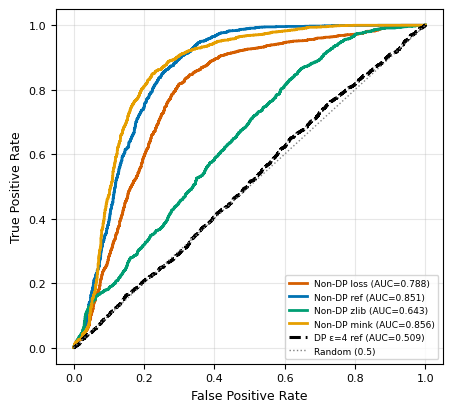

In [49]:
PALETTE_SIGNAL = {
    "loss": COLOR_DP,      # vermillion
    "ref":  COLOR_FULL_FT, # blue -- primary signal
    "zlib": COLOR_MICA,    # green
    "mink": COLOR_LORA,    # orange
}


def fig4c_dp_vs_all_signals(n_members: int = 2000, epoch: int = 5, dp_eps: float = 4):
    nondp_path = RESULTS_DIR / f"signals_N{n_members}_seed0_epoch{epoch}.jsonl"
    dp_path    = RESULTS_DIR / f"signals_dp_eps{dp_eps:g}_N{n_members}_seed0_epoch{epoch}.jsonl"
    assert nondp_path.exists(), f"Figure 4c: missing non-DP baseline {nondp_path.name}"
    assert dp_path.exists(), f"Figure 4c: missing DP file {dp_path.name} -- check available (N, epoch, eps) combos in metrics_all.csv"

    fig, ax = plt.subplots(figsize=(4.6, 4.2))

    for signal in ALL_SIGNALS:
        auroc, fpr, tpr = sklearn_auroc(nondp_path, signal)
        ax.plot(fpr, tpr, color=PALETTE_SIGNAL[signal], lw=2,
                label=f"Non-DP {signal} (AUC={auroc:.3f})")

    auroc_dp, fpr_dp, tpr_dp = sklearn_auroc(dp_path, PRIMARY_SIGNAL)
    ax.plot(fpr_dp, tpr_dp, color="black", lw=2.2, ls="--",
            label=f"DP \u03b5={dp_eps:g} {PRIMARY_SIGNAL} (AUC={auroc_dp:.3f})")

    ax.plot([0, 1], [0, 1], color="gray", ls=":", lw=1, label="Random (0.5)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    #ax.set_title(f"Non-DP (all signals) vs DP \u03b5={dp_eps:g} (N={n_members:,}, epoch={epoch})",
    #             fontsize=9)
    ax.legend(fontsize=6.5, loc="lower right")
    fig.tight_layout()
    save_fig(fig, f"fig4c_dp_vs_signals_N{n_members}_epoch{epoch}_eps{dp_eps:g}")
    plt.show()


fig4c_dp_vs_all_signals(n_members=2000, epoch=5, dp_eps=4)


## Summary table

`signal == 'ref'`, full fine-tuning only, across all `(n_members, epochs)` combinations: mean
and std (over the 3 seeds) of `adv`, `bh_seq`, and `adv_over_bound_seq`.


In [50]:
def build_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    sub = df[
        (df["signal"] == "ref")
        & df["lora_rank"].isna()
        & df["mica_rank"].isna()
        & df["dp_epsilon"].isna()
    ].copy()
    assert not sub.empty, "Summary table: no full-FT signal=ref rows found"

    agg = (
        sub.groupby(["n_members", "epochs"])[["adv", "bh_seq", "adv_over_bound_seq"]]
        .agg(["mean", "std"])
        .reset_index()
    )
    agg.columns = ["n_members", "epochs"] + [f"{c}_{s}" for c, s in agg.columns[2:]]
    agg = agg.sort_values(["n_members", "epochs"]).reset_index(drop=True)
    return agg


summary_table = build_summary_table(metrics_all)
out_path = FIGURES_DIR / "summary_table.csv"
summary_table.to_csv(out_path, index=False)
print(f"  saved -> {out_path.relative_to(ROOT)}")

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
summary_table


  saved -> figures\summary_table.csv


,n_members,epochs,adv_mean,adv_std,bh_seq_mean,bh_seq_std,adv_over_bound_seq_mean,adv_over_bound_seq_std
0,500,1,0.3458,0.0133,0.8346,0.0068,0.4143,0.0150
1,500,2,0.5068,0.0141,0.9406,0.0128,0.4868,0.0185
2,500,3,0.6130,0.0113,0.9761,0.0063,0.4948,0.0172
3,500,5,0.7613,0.0108,0.9975,0.0007,0.4662,0.0062
4,500,10,0.8973,0.0086,0.9998,0.0000,0.4470,0.0082
5,500,15,0.9295,0.0074,0.9999,0.0000,0.4419,0.0068
6,500,20,0.9408,0.0070,1.0000,0.0000,0.4337,0.0101
7,2000,1,0.2553,0.0038,0.7093,0.0303,0.3603,0.0126
8,2000,2,0.3677,0.0020,0.8584,0.0109,0.4284,0.0053
9,2000,3,0.4543,0.0089,0.8777,0.0659,0.5054,0.0423


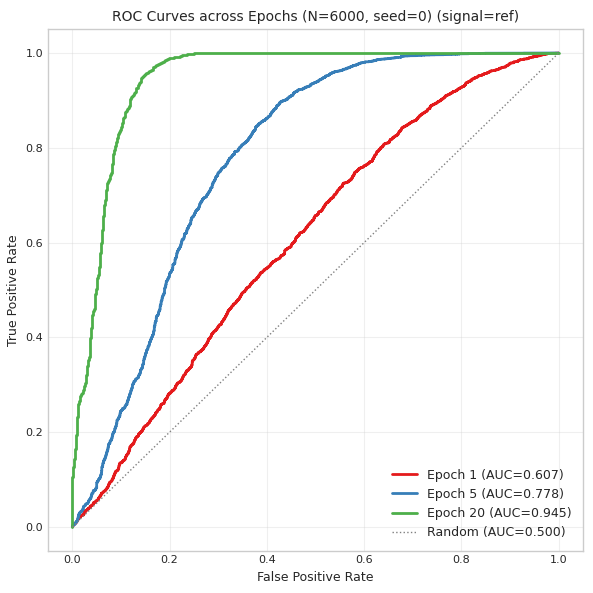

In [51]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sklearn_auc

from config import RESULTS_DIR, FIGURES_DIR, FIG_DPI, PRIMARY_SIGNAL
from metrics.compute_metrics import load_scores

STYLE = "seaborn-v0_8-whitegrid"


def plot_roc_curve(ax, scores_members, scores_nonmembers, color, ls="-", lw=2, label=""):
    """Draw one ROC curve (member vs non-member attack scores) on ax, with
    its AUC appended to the legend label. Returns the AUC."""
    labels = [1] * len(scores_members) + [0] * len(scores_nonmembers)
    scores = list(scores_members) + list(scores_nonmembers)
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = float(sklearn_auc(fpr, tpr))
    ax.plot(fpr, tpr, color=color, ls=ls, lw=lw, label=f"{label} (AUC={roc_auc:.3f})")
    return roc_auc


def plot_roc_curves(
    curves: list[tuple[str, Path, str]],
    signal: str = PRIMARY_SIGNAL,
    title: str = "ROC Curve",
    save_name: str | None = None,
):
    """
    Plot ROC curve(s) (TPR vs FPR) for one or more signal files on a single axis.

    curves: list of (label, signals_path, color) tuples, e.g.
        [("Epoch 5", RESULTS_DIR / "signals_N6000_seed0_epoch5.jsonl", "black"),
         ("Epoch 20", RESULTS_DIR / "signals_N6000_seed0_epoch20.jsonl", "#377eb8")]
    signal: which attack signal to use ("loss", "ref", "zlib", "mink")
    save_name: if given, saves the figure to FIGURES_DIR / save_name
    """
    with plt.style.context(STYLE):
        fig, ax = plt.subplots(figsize=(6, 6))

        for label, path, color in curves:
            sc_m, sc_nm = load_scores(Path(path))[signal]
            plot_roc_curve(ax, sc_m, sc_nm, color, ls="-", label=label)

        ax.plot([0, 1], [0, 1], color="gray", ls=":", lw=1, label="Random (AUC=0.500)")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"{title} (signal={signal})")
        ax.legend(fontsize=9, loc="lower right")
        fig.tight_layout()

        if save_name:
            out = FIGURES_DIR / save_name
            fig.savefig(out, dpi=FIG_DPI, bbox_inches="tight")
            print(f"Saved to {out}")

    return fig, ax

fig, ax = plot_roc_curves(
    curves=[
        ("Epoch 1",  RESULTS_DIR / "signals_N6000_seed0_epoch1.jsonl",  "#e41a1c"),
        ("Epoch 5",  RESULTS_DIR / "signals_N6000_seed0_epoch5.jsonl",  "#377eb8"),
        ("Epoch 20", RESULTS_DIR / "signals_N6000_seed0_epoch20.jsonl", "#4daf4a"),
    ],
    signal="ref",
    title="ROC Curves across Epochs (N=6000, seed=0)",
)
